**Simulación para póster**

▫ This is OptimalControl version v1.1.1 running with: direct, adnlp, ipopt.

▫ The optimal control problem is solved with CTDirect version v0.16.3.

ADNLPModels and solved with NLPModelsIpopt.
   │
   ├─ Number of time steps⋅: 2000
   └─ Discretisation scheme: trapeze

▫ This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    96007
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    14007

Total number of variables............................:    16008
                     variables with only lower bounds:        0
                variables with lower and upper bounds:     2001
                     variables with only upper bounds:        0
Total number of equality constraints.................:    14007
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality c

┌ Warning: could not parse Ipopt log file. SystemError("opening file \"C:\\\\Users\\\\Alfredo\\\\AppData\\\\Local\\\\Temp\\\\jl_F81gTY9q9e\"", 13, nothing)
└ @ NLPModelsIpopt C:\Users\Alfredo\.julia\packages\NLPModelsIpopt\OGzSv\src\NLPModelsIpopt.jl:297
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


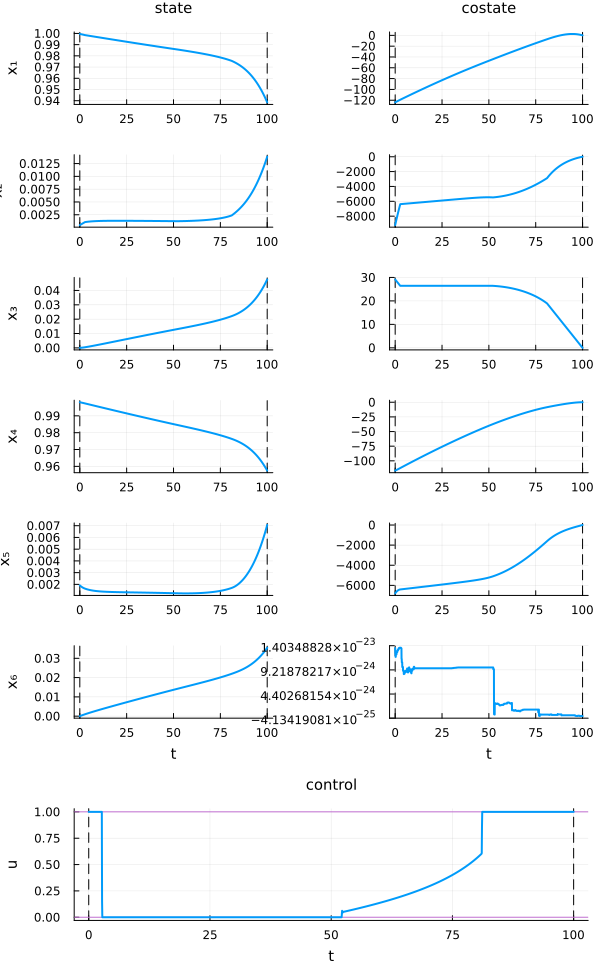

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Alfredo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


LoadError: TypeError: in keyword argument layout, expected Symbol, got a value of type Matrix{Any}

In [1]:
using OptimalControl
using NLPModelsIpopt
using Plots
using JuMP
using HiGHS
import Pkg
import Ipopt
import DifferentialEquations as DE

#Parámetros del sistema
beta1 = 0.10 #tasa de transmisión de la enfermedad fuera de la escuela
beta2 = 0.15 #tasa de transmisión de la enfermedad dentro de la escuela
gamma  = 0.20 #tasa de recuperación de la enfermedad
lambdaE = 1.0 #ponderador de beneficio de la apertura
lambdaI = 50.0 #ponderador de penalización de infectados
T  = 100  #duración de la simulación

#Definimos el problema de control óptimo
ocp = @def begin
    t ∈ [0, T], time
    x ∈ R⁶, state      #los 6 estados del modelo [SE, IE, RE, SNE, INE, RNE]
    u ∈ R, control     #control cuantifica la reapertura de la escuela

    #Condiciones iniciales
    x(0) == [0.999521, 0.000479, 0.0, 0.998086, 0.001914, 0.0]

    #Dinámica del modelo
    ẋ(t) == [
        -beta1 * x₁(t) * (x₂(t) + x₅(t)) - u(t) * beta2 * x₁(t) * x₂(t),               # ecuación SE'
         beta1 * x₁(t) * (x₂(t) + x₅(t)) + u(t) * beta2 * x₁(t) * x₂(t) - gamma*x₂(t),   # ecuación IE'
         gamma * x₂(t),                                                                # ecuación RE'
        -beta1 * x₄(t) * (x₂(t) + x₅(t)),                                              # ecuación SNE'
         beta1 * x₄(t) * (x₂(t) + x₅(t)) - gamma * x₅(t),                              # ecuación INE'
         gamma * x₅(t)                                                                 # ecuación RNE'
    ]

    #Defino la función objetivo (minimizar J(u))
    ∫(lambdaE * u(t) * (x₁(t) + x₃(t)) - lambdaI * (x₂(t) + x₅(t)) ) → max

    #Restricciones para el control
    0 ≤ u(t) ≤ 1 
end

#Resolver el problema
sol2 = solve(ocp, grid_size=2000)

#Graficar resultados
p1 = plot(sol2, vars=(0, :u), title="Control óptimo u(t)", xlabel="Tiempo", ylabel="Apertura")
display(p1)

p2 = plot(sol2, vars=(0, 1:6), layout = @layout([a b; c d; e f]),title="Evolución de estados", legend=false)
display(p2)

In [2]:
using LinearAlgebra

function calculaR0(beta1, beta2, gamma, NE, NNE, u)
    #Matriz de Siguiente Generación K = F * V⁻¹
    K = (1/gamma) * [
        (beta1 + u * beta2) * NE   beta1 * NE ; 
        beta1 * NNE                beta1 * NNE
    ]
    
    #Calcular los valores propios
    lambda = eigvals(K)
    
    #R₀ es el valor propio con mayor magnitud
    return maximum(abs.(lambda))
end

#R0 con escuela cerrada, población totalmente susceptible
R0_cerrada = calculaR0(beta1, beta2, gamma, 1, 1, 0)

#R0 con escuela abierta al 100%, población totalmente susceptible
R0_abierta = calculaR0(beta1, beta2, gamma, 1, 1, 1)

println("R0 (con escuela Cerrada, u=0): ", R0_cerrada)
println("R0 (con escuela Abierta, u=1): ", R0_abierta)

R0 (con escuela Cerrada, u=0): 1.0
R0 (con escuela Abierta, u=1): 1.5


In [3]:
using LinearAlgebra
using Plots # Asegúrate de que Plots está en el script para la gráfica

# Definición de la función Rt(t) usando la Matriz de Siguiente Generación (NGM)
function calculoRt(state, u, β1, β2, γ)
    SE, IE, RE, SNE, INE, RNE = state

    # Matriz F (nuevas infecciones)
    F = [
        (β1 + u * β2) * SE       β1 * SE
        β1 * SNE                 β1 * SNE
    ]

    # Matriz de Siguiente Generación K = F * V⁻¹ = F / γ
    K = F / γ
    
    # Valores propios
    vals = eigvals(K)
    
    # Rt es el valor propio más grandes
    return maximum(abs.(vals)) 
end



ts = sol.time_grid.value       # vector de tiempos discretos
state_fun = sol.state.value    # función interpolada del estado x(t)
control_fun = sol.control.value # función interpolada del control u(t)


#Calcular Rt
Rt_vals = [calculoRt(state_fun(t), control_fun(t), beta1, beta2, gamma) for t in ts]

# Graficar el resultado
p4 = plot(ts, Rt_vals, 
    xlabel="Tiempo", ylabel="Rt", 
    title="Evolución del Número Efectivo Reproductivo Rt",
    label=false,
    linewidth=3)


# Añadir la línea crítica Rt = 1
hline!([1], line=:dash, color=:red,label=false) 

display(p4)

LoadError: UndefVarError: `sol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [4]:
ts2 = sol2.time_grid.value       # vector de tiempos discretos
state_fun2 = sol2.state.value    # función interpolada del estado x(t)
costate_fun2 = sol2.costate # función interpolada del control u(t)


#Calcular phi(t)
phi_vals2 = [conmutación(state_fun2(t), costate_fun2(t), lambdaE, beta2) for t in ts]
control_fun2 = sol2.control.value
control_vals2 = [control_fun2(t) for t in ts]

using Plots, LaTeXStrings
# Graficar el resultado
p5 = plot(ts2, phi_vals2, 
    xlabel="Tiempo", ylabel="Valores de las funciones", 
    title="Evolución de la función de conmutación \n y el control óptimo ",
    label=false,
    linewidth=3)
plot!(ts2, control_vals2, label = false)

display(p5)

LoadError: UndefVarError: `ts` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

**Comentario**

Se ocupa el mismo estado inicial y los mismos parámetros salvo que se penaliza mucho más la infección, por lo tanto damos $\lambda_E= 0.1$ y $\lambda_I = 100$

El $R_0$ continua igual ya que no depende de $\lambda_E $ y $\lambda_I$

Sobre la evolución del $R_t(t)$: 

La gráfica de $R_t(t)$ refleja la política de control: Para ($t \in [0, 90]$):$ R_t(0) \approx 1.0$. Esto significa que con el control $u=0$ aplicado inmediatamente, el numéro efectivo $R_t$ es igual al $R_0$ con escuela cerrada, que era $1.0$. A partir de ahí, el $R_t$ baja constantemente por debajo de 1 debido a la disminución de susceptibles. Luego hay un shock por la reapertura total de escuelas (para $t \approx 90$), esto ocurre cuando el control salta a $u=1$, el $R_t(t)$ experimenta un salto brusco a un valor $\approx 1.45$.

In [1]:
using JuMP
using HiGHS
import Pkg
import Ipopt
import DifferentialEquations as DE
using Pkg
    Pkg.add("XLSX")

   Resolving package versions...
  No Changes to `C:\Users\Alfredo\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\Alfredo\.julia\environments\v1.11\Manifest.toml`


In [2]:
using XLSX

xf = XLSX.readxlsx("C:/Users/Alfredo/Documents/Control Óptimo/Proyecto - Reapertura Pandemia/series.xlsx")[1]
fechas = xf["C1:AWD1"]
sec = xf["C2:AWD2"]

D = 10
L = length(sec)
casos_activos = zeros(L)
INE_dias = zeros(L)

for t in 1:L
    suma_activos = 0.0
    for k in 1:D
        dia_inicio = t - k + 1
        if dia_inicio >= 1
            suma_activos += sec[dia_inicio]
        end
    end
    casos_activos[t] = suma_activos
    INE_dias[t] = div(casos_activos[t]*4,5)
end

In [3]:
function pobl(dia)
    R = sum(sec[i] for i in 1:dia-10)
    RE = div(R,5)
    RNE = R - RE
    I = casos_activos[dia]
    IE = div(I,5)
    INE_n = I - IE
    S = 18480432 - I - R
    SE = div(S,5)
    SNE = S - SE
    return [SE, IE, RE, SNE, INE_n, RNE]
end

init_data = pobl(370)

6-element Vector{Float64}:
      3.530385e6
   8711.0
 156990.0
      1.412154e7
  34844.0
 627962.0

In [4]:
function INE1(t)
    if t < 0 || t > 1275
        if t < 0
            return INE_dias[1]
        else
            return INE_dias[1276]
        end
    end
    ind_t = floor(Int, t) + 1 
    if ind_t == 1276
        return INE_dias[1276]
    end

    x1 = ind_t - 1
    y1 = INE_dias[ind_t]
    x2 = ind_t
    y2 = INE_dias[ind_t+1]
    m = y2 - y1
    return y1 + m * (t - x1)
end

function INE(t)
    return INE1(t+370)
end

INE (generic function with 1 method)

In [ ]:
using OptimalControl
using NLPModelsIpopt
using Plots

#Parámetros del sistema
beta1 = 10 #tasa de transmisión de la enfermedad fuera de la escuela
beta2 = 15 #tasa de transmisión de la enfermedad dentro de la escuela
gamma  = 3 #tasa de recuperación de la enfermedad
lambdaE = 1.0 #ponderador de beneficio de la apertura
lambdaI = 1.0 #ponderador de penalización de infectados
T  = 50  #duración de la simulación

#Definimos el problema de control óptimo
ocp = @def begin
    t ∈ [0, 50], time
    x ∈ R³, state      #los 3 estados del modelo [SE, IE, RE]
    u ∈ R, control     #control cuantifica la reapertura de la escuela

    #Condiciones iniciales
    x(0) == [3530385.0, 8711.0, 156990.0]

    #Dinámica del modelo
    ẋ(t) == [
        -beta1 * x₁(t) * (x₂(t) + INE1(t)) - u(t) * beta2 * x₁(t) * x₂(t),               # ecuación SE'
         beta1 * x₁(t) * (x₂(t) + INE1(t)) + u(t) * beta2 * x₁(t) * x₂(t) - gamma*x₂(t),   # ecuación IE'
         gamma * x₂(t)                                                                # ecuación RE'
    ]

    #Defino la función objetivo (minimizar J(u))
    ∫( -lambdaE * u(t) * (x₁(t) + x₃(t)) + lambdaI * x₂(t)) → min

    #Restricciones para el control
    0 ≤ u(t) ≤ 1 
end

#Resolver el problema
sol = solve(ocp, grid_size=200)

#Graficar resultados
p1 = plot(sol, vars=(0, :u), title="Control óptimo u(t)", xlabel="Tiempo", ylabel="Apertura")
display(p1)

p2 = plot(sol, vars=(0, 1:3), layout = @layout([a b c]),title="Evolución de estados", legend=false)
display(p2)

▫ This is OptimalControl version v1.1.1 running with: direct, adnlp, ipopt.

▫ The optimal control problem is solved with CTDirect version v0.16.3.

   ┌─ The NLP is modelled with 